# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Nama Anda
- **Email Dicoding:** email@dicoding.com
- **ID Dicoding:** id_dicoding
- **Dataset:** Capital Bikeshare Washington D.C. (2011–2012)


## 1. Menentukan Pertanyaan Bisnis

Berikut adalah dua pertanyaan bisnis yang akan dijawab melalui analisis ini, dirumuskan dengan metode **SMART Question**:

### Pertanyaan 1
> **Bagaimana pola rata-rata jumlah penyewaan sepeda per jam antara hari kerja (workingday) dan hari libur/akhir pekan sepanjang periode 2011–2012, dan pada jam berapa permintaan sewa mencapai puncak tertinggi?**

| Kriteria | Penjelasan |
|----------|------------|
| **Specific** | Fokus pada pola per jam, dibedakan berdasarkan tipe hari (kerja vs. libur) |
| **Measurable** | Menggunakan rata-rata jumlah sewa (`cnt`) per jam (`hr`) |
| **Action-Oriented** | Mengetahui jam puncak memungkinkan operator menyesuaikan distribusi armada sepeda |
| **Relevant** | Pola permintaan per jam adalah kunci efisiensi operasional layanan bike sharing |
| **Time-bound** | Dibatasi pada data tahun 2011–2012 |

### Pertanyaan 2
> **Faktor lingkungan apa (musim, kondisi cuaca, suhu) yang paling berpengaruh terhadap rata-rata jumlah penyewaan sepeda harian pada periode 2011–2012, dan seberapa besar perbedaannya antar kategori?**

| Kriteria | Penjelasan |
|----------|------------|
| **Specific** | Fokus pada faktor musim, kondisi cuaca, dan kelompok suhu |
| **Measurable** | Menggunakan rata-rata `cnt` per kategori faktor lingkungan |
| **Action-Oriented** | Membantu manajemen merencanakan promosi atau penambahan armada saat kondisi optimal |
| **Relevant** | Faktor cuaca secara langsung memengaruhi minat pengguna untuk bersepeda |
| **Time-bound** | Menggunakan seluruh rentang data 2011–2012 |


## 2. Data Wrangling

### 2.1 Gathering Data

Memuat kedua dataset (daily dan hourly) ke dalam DataFrame.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# Load data
df_day  = pd.read_csv('data/day.csv')
df_hour = pd.read_csv('data/hour.csv')

print('Shape day  :', df_day.shape)
print('Shape hour :', df_hour.shape)
df_day.head()


Shape day  : (731, 16)
Shape hour : (17379, 17)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


### 2.2 Assessing Data

Menilai kualitas data dengan memeriksa missing value, duplikasi, tipe data, dan nilai yang tidak konsisten.

In [2]:
# ── Missing values ──────────────────────────────────────────────
print('=== Missing Values (day) ===')
print(df_day.isnull().sum())
print('\n=== Missing Values (hour) ===')
print(df_hour.isnull().sum())


=== Missing Values (day) ===
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

=== Missing Values (hour) ===
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [3]:
# ── Duplicate rows ───────────────────────────────────────────────
print('Duplicate rows in df_day :', df_day.duplicated().sum())
print('Duplicate rows in df_hour:', df_hour.duplicated().sum())


Duplicate rows in df_day : 0
Duplicate rows in df_hour: 0


In [4]:
# ── Data types ───────────────────────────────────────────────────
print('=== Data Types (day) ===')
print(df_day.dtypes)


=== Data Types (day) ===
instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


In [5]:
# ── Range check (inaccurate values) ─────────────────────────────
print('temp range  :', df_day['temp'].min(), '-', df_day['temp'].max(),  '  (expected 0–1)')
print('hum range   :', df_day['hum'].min(),  '-', df_day['hum'].max(),   '  (expected 0–1)')
print('season vals :', sorted(df_day['season'].unique()),  '  (expected 1-4)')
print('weathersit  :', sorted(df_day['weathersit'].unique()), '  (expected 1-4)')

# Potential issue: humidity = 0 is physically implausible
zero_hum = df_day[df_day['hum'] == 0]
print(f'\nRows with hum == 0 in df_day: {len(zero_hum)}')
print(zero_hum[['dteday','hum','temp','cnt']])


temp range  : 0.0591304 - 0.861667   (expected 0–1)
hum range   : 0.0 - 0.9725   (expected 0–1)
season vals : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]   (expected 1-4)
weathersit  : [np.int64(1), np.int64(2), np.int64(3)]   (expected 1-4)

Rows with hum == 0 in df_day: 1
        dteday  hum      temp  cnt
68  2011-03-10  0.0  0.389091  623


In [6]:
# ── Inconsistent data types: dteday stored as object ─────────────
print('dteday dtype (day) :', df_day['dteday'].dtype)
print('Sample dteday:', df_day['dteday'].head(3).tolist())


dteday dtype (day) : str
Sample dteday: ['2011-01-01', '2011-01-02', '2011-01-03']


#### Temuan Assessing Data

| # | Masalah | Kolom | Tindakan |
|---|---------|-------|----------|
| 1 | **Tipe data tidak sesuai** | `dteday` tersimpan sebagai `object` bukan `datetime64` | Konversi ke `datetime64` |
| 2 | **Nilai tidak masuk akal (Inaccurate Value)** | `hum == 0` pada 1 baris di `df_day` | Ganti dengan median kelembaban |
| 3 | **Kolom kode perlu dilabeli** | `season`, `weathersit`, `weekday`, `yr` berupa kode integer | Tambahkan kolom label kategoris |


### 2.3 Cleaning Data

In [7]:
# ── Fix 1: Convert dteday to datetime ───────────────────────────
df_day['dteday']  = pd.to_datetime(df_day['dteday'])
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])
print('dteday dtype after fix:', df_day['dteday'].dtype)


dteday dtype after fix: datetime64[us]


In [8]:
# ── Fix 2: Replace hum == 0 with median ─────────────────────────
med_hum = df_day.loc[df_day['hum'] > 0, 'hum'].median()
df_day.loc[df_day['hum'] == 0, 'hum'] = med_hum
print('Rows with hum==0 after fix:', (df_day['hum'] == 0).sum())
print(f'Replaced with median hum = {med_hum:.4f}')


Rows with hum==0 after fix: 0
Replaced with median hum = 0.6271


In [9]:
# ── Fix 3: Add descriptive label columns ────────────────────────
season_map     = {1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'}
weather_map    = {1:'Clear', 2:'Mist/Cloudy', 3:'Light Rain/Snow', 4:'Heavy Rain/Snow'}
weekday_map    = {0:'Sun', 1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat'}
yr_map         = {0:2011, 1:2012}

for df in [df_day, df_hour]:
    df['season_label']  = df['season'].map(season_map)
    df['weather_label'] = df['weathersit'].map(weather_map)
    df['weekday_label'] = df['weekday'].map(weekday_map)
    df['year']          = df['yr'].map(yr_map)

print('Cleaned day shape  :', df_day.shape)
print('Cleaned hour shape :', df_hour.shape)
df_day[['dteday','season_label','weather_label','weekday_label','year','hum']].head()


Cleaned day shape  : (731, 20)
Cleaned hour shape : (17379, 21)


,dteday,season_label,weather_label,weekday_label,year,hum
0,2011-01-01,Spring,Mist/Cloudy,Sat,2011,0.805833
1,2011-01-02,Spring,Mist/Cloudy,Sun,2011,0.696087
2,2011-01-03,Spring,Clear,Mon,2011,0.437273
3,2011-01-04,Spring,Clear,Tue,2011,0.590435
4,2011-01-05,Spring,Clear,Wed,2011,0.436957


## 3. Exploratory Data Analysis (EDA)

### EDA – Pertanyaan 1: Pola Penyewaan Per Jam (Workingday vs. Non-Workingday)

In [10]:
# Hourly average split by workingday
hourly_wd  = df_hour[df_hour['workingday'] == 1].groupby('hr')['cnt'].mean()
hourly_nwd = df_hour[df_hour['workingday'] == 0].groupby('hr')['cnt'].mean()

print('=== Hari Kerja ===')
print('Jam puncak         :', hourly_wd.idxmax(), '(rata-rata', round(hourly_wd.max(),1), 'sewa)')
print('Jam paling sepi    :', hourly_wd.idxmin(), '(rata-rata', round(hourly_wd.min(),1), 'sewa)')

print('\n=== Hari Libur/Akhir Pekan ===')
print('Jam puncak         :', hourly_nwd.idxmax(), '(rata-rata', round(hourly_nwd.max(),1), 'sewa)')
print('Jam paling sepi    :', hourly_nwd.idxmin(), '(rata-rata', round(hourly_nwd.min(),1), 'sewa)')


=== Hari Kerja ===
Jam puncak         : 17 (rata-rata 525.3 sewa)
Jam paling sepi    : 3 (rata-rata 4.9 sewa)

=== Hari Libur/Akhir Pekan ===
Jam puncak         : 13 (rata-rata 372.7 sewa)
Jam paling sepi    : 4 (rata-rata 8.3 sewa)


In [11]:
# Peak-hour comparison table
peak_df = pd.DataFrame({
    'Jam': range(24),
    'Hari Kerja': hourly_wd.values.round(1),
    'Hari Libur': hourly_nwd.values.round(1)
})
peak_df['Selisih'] = (peak_df['Hari Kerja'] - peak_df['Hari Libur']).round(1)
print(peak_df.to_string(index=False))


 Jam  Hari Kerja  Hari Libur  Selisih
   0        36.8        90.8    -54.0
   1        16.6        69.5    -52.9
   2         8.7        53.2    -44.5
   3         4.9        25.8    -20.9
   4         5.4         8.3     -2.9
   5        24.9         8.7     16.2
   6       102.5        18.7     83.8
   7       290.6        43.4    247.2
   8       477.0       105.7    371.3
   9       241.5       171.6     69.9
  10       135.4       255.9   -120.5
  11       158.2       315.3   -157.1
  12       200.8       366.3   -165.5
  13       198.4       372.7   -174.3
  14       183.6       364.6   -181.0
  15       201.3       358.8   -157.5
  16       293.1       352.7    -59.6
  17       525.3       323.5    201.8
  18       492.2       281.1    211.1
  19       348.4       231.7    116.7
  20       249.7       174.7     75.0
  21       186.3       142.1     44.2
  22       138.4       116.1     22.3
  23        88.7        85.9      2.8


### EDA – Pertanyaan 2: Pengaruh Faktor Lingkungan terhadap Penyewaan Harian

In [12]:
# Season effect
season_stats = df_day.groupby('season_label')['cnt'].agg(['mean','median','std']).round(1)
season_stats.columns = ['Mean', 'Median', 'Std']
print('=== Rata-rata Sewa per Musim ===')
print(season_stats.sort_values('Mean', ascending=False))

# Weather effect
weather_stats = df_day.groupby('weather_label')['cnt'].agg(['mean','count']).round(1)
weather_stats.columns = ['Mean Sewa', 'Jumlah Hari']
print('\n=== Rata-rata Sewa per Kondisi Cuaca ===')
print(weather_stats.sort_values('Mean Sewa', ascending=False))


=== Rata-rata Sewa per Musim ===
                Mean  Median     Std
season_label                        
Fall          5644.3  5353.5  1459.8
Summer        4992.3  4941.5  1696.0
Winter        4728.2  4634.5  1699.6
Spring        2604.1  2209.0  1399.9

=== Rata-rata Sewa per Kondisi Cuaca ===
                 Mean Sewa  Jumlah Hari
weather_label                          
Clear               4876.8          463
Mist/Cloudy         4035.9          247
Light Rain/Snow     1803.3           21


In [13]:
# Temperature clustering using binning
df_day['temp_actual'] = df_day['temp'] * 41  # denormalize (max=41°C)
df_hour['temp_actual'] = df_hour['temp'] * 41

bins   = [0, 10, 20, 30, 41]
labels = ['Sangat Dingin (0-10°C)', 'Dingin (10-20°C)', 'Hangat (20-30°C)', 'Panas (30-41°C)']
df_day['temp_cluster'] = pd.cut(df_day['temp_actual'], bins=bins, labels=labels, right=True)

temp_stats = df_day.groupby('temp_cluster', observed=True)['cnt'].agg(['mean','count']).round(1)
temp_stats.columns = ['Mean Sewa', 'Jumlah Hari']
print('=== Rata-rata Sewa per Kluster Suhu ===')
print(temp_stats)


=== Rata-rata Sewa per Kluster Suhu ===
                        Mean Sewa  Jumlah Hari
temp_cluster                                  
Sangat Dingin (0-10°C)     1677.8           60
Dingin (10-20°C)           3692.3          299
Hangat (20-30°C)           5661.7          300
Panas (30-41°C)            5410.0           72


In [14]:
# Yearly growth
print('=== Pertumbuhan Tahunan ===')
yearly = df_day.groupby('year')['cnt'].agg(['sum','mean']).round(1)
yearly.columns = ['Total Sewa', 'Rata-rata/Hari']
print(yearly)
growth = (yearly.loc[2012,'Total Sewa'] - yearly.loc[2011,'Total Sewa']) / yearly.loc[2011,'Total Sewa'] * 100
print(f'\nGrowth 2011→2012: {growth:.1f}%')


=== Pertumbuhan Tahunan ===
      Total Sewa  Rata-rata/Hari
year                            
2011     1243103          3405.8
2012     2049576          5599.9

Growth 2011→2012: 64.9%


In [15]:
# Correlation heatmap data
corr_cols = ['temp_actual','atemp','hum','windspeed','casual','registered','cnt']
print('=== Korelasi dengan cnt ===')
print(df_day[corr_cols].corr()['cnt'].sort_values(ascending=False).round(3))


=== Korelasi dengan cnt ===
cnt            1.000
registered     0.946
casual         0.673
atemp          0.631
temp_actual    0.627
hum           -0.114
windspeed     -0.235
Name: cnt, dtype: float64


## 4. Visualization & Explanatory Analysis

### Visualisasi 1: Pola Penyewaan Per Jam – Hari Kerja vs. Hari Libur

Visualisasi ini menjawab **Pertanyaan Bisnis 1**.

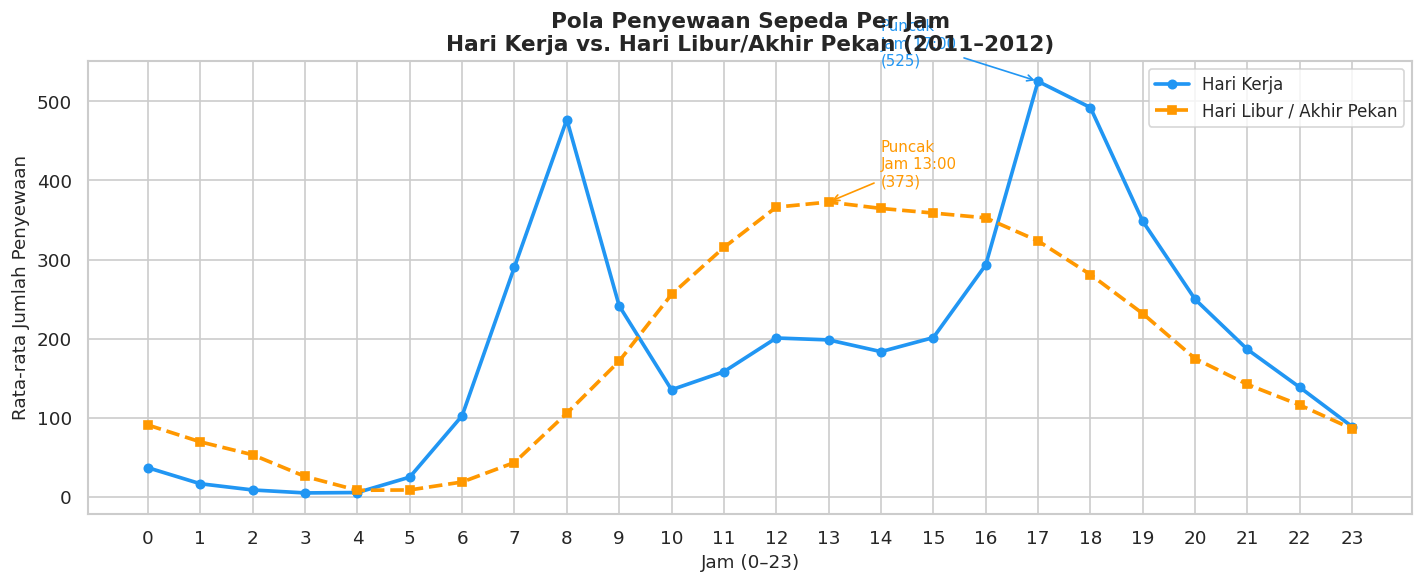

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(hourly_wd.index,  hourly_wd.values,  marker='o', linewidth=2.2,
        color='#2196F3', label='Hari Kerja',  markersize=5)
ax.plot(hourly_nwd.index, hourly_nwd.values, marker='s', linewidth=2.2,
        color='#FF9800', label='Hari Libur / Akhir Pekan', markersize=5, linestyle='--')

# Annotate peaks
ax.annotate(f'Puncak\nJam {hourly_wd.idxmax()}:00\n({hourly_wd.max():.0f})',
            xy=(hourly_wd.idxmax(), hourly_wd.max()),
            xytext=(hourly_wd.idxmax()-3, hourly_wd.max()+20),
            arrowprops=dict(arrowstyle='->', color='#2196F3'), color='#2196F3', fontsize=9)
ax.annotate(f'Puncak\nJam {hourly_nwd.idxmax()}:00\n({hourly_nwd.max():.0f})',
            xy=(hourly_nwd.idxmax(), hourly_nwd.max()),
            xytext=(hourly_nwd.idxmax()+1, hourly_nwd.max()+20),
            arrowprops=dict(arrowstyle='->', color='#FF9800'), color='#FF9800', fontsize=9)

ax.set_xticks(range(0, 24))
ax.set_xlabel('Jam (0–23)', fontsize=11)
ax.set_ylabel('Rata-rata Jumlah Penyewaan', fontsize=11)
ax.set_title('Pola Penyewaan Sepeda Per Jam\nHari Kerja vs. Hari Libur/Akhir Pekan (2011–2012)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('viz_hourly_pattern.png', bbox_inches='tight')
plt.show()


**Insight:** Pada hari kerja terdapat dua puncak permintaan yang jelas (bimodal) yaitu pagi pukul 08:00 dan sore pukul 17:00–18:00, mencerminkan pola komuter. Sebaliknya, pada hari libur/akhir pekan pola lebih landai dengan puncak tunggal di tengah hari (11:00–14:00).

### Visualisasi 2a: Rata-rata Sewa per Musim

Visualisasi ini menjawab sebagian **Pertanyaan Bisnis 2** (aspek musim).

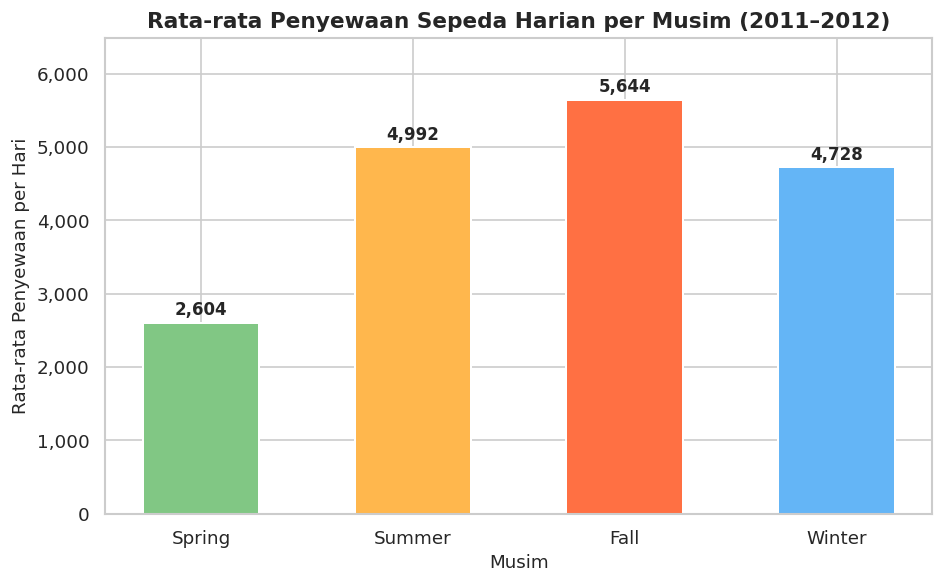

In [17]:
season_order = ['Spring','Summer','Fall','Winter']
season_avg   = df_day.groupby('season_label')['cnt'].mean().reindex(season_order)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#81C784','#FFB74D','#FF7043','#64B5F6']
bars = ax.bar(season_avg.index, season_avg.values, color=colors, edgecolor='white', linewidth=1.2, width=0.55)

for bar, val in zip(bars, season_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 50, f'{val:,.0f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Musim', fontsize=11)
ax.set_ylabel('Rata-rata Penyewaan per Hari', fontsize=11)
ax.set_title('Rata-rata Penyewaan Sepeda Harian per Musim (2011–2012)', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(0, season_avg.max() * 1.15)
plt.tight_layout()
plt.savefig('viz_season.png', bbox_inches='tight')
plt.show()


### Visualisasi 2b: Rata-rata Sewa per Kondisi Cuaca & Kluster Suhu

Visualisasi ini menjawab **Pertanyaan Bisnis 2** (aspek cuaca dan suhu).

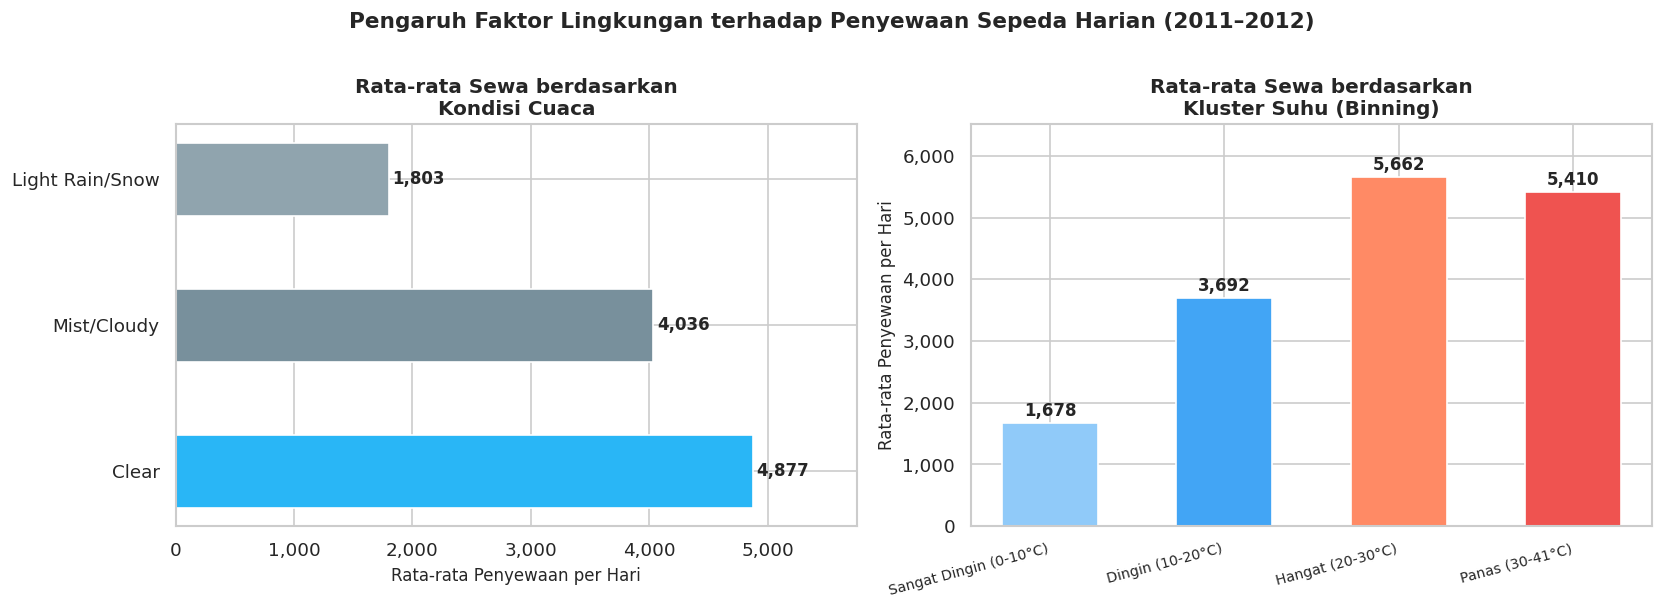

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── subplot 1: weathersit ─────────────────────────────────────────
weather_avg = df_day.groupby('weather_label')['cnt'].mean().sort_values(ascending=False)
ax = axes[0]
wcolors = ['#29B6F6','#78909C','#90A4AE']
bars = ax.barh(weather_avg.index, weather_avg.values, color=wcolors, edgecolor='white', height=0.5)
for bar, val in zip(bars, weather_avg.values):
    ax.text(val + 30, bar.get_y() + bar.get_height()/2, f'{val:,.0f}',
            va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Rata-rata Penyewaan per Hari', fontsize=10)
ax.set_title('Rata-rata Sewa berdasarkan\nKondisi Cuaca', fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, weather_avg.max() * 1.18)

# ── subplot 2: temperature cluster ───────────────────────────────
temp_avg = df_day.groupby('temp_cluster', observed=True)['cnt'].mean()
ax2 = axes[1]
tcolors = ['#90CAF9','#42A5F5','#FF8A65','#EF5350']
bars2 = ax2.bar(range(len(temp_avg)), temp_avg.values, color=tcolors, edgecolor='white', width=0.55)
ax2.set_xticks(range(len(temp_avg)))
ax2.set_xticklabels(temp_avg.index, fontsize=8.5, rotation=15, ha='right')
for bar, val in zip(bars2, temp_avg.values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 50, f'{val:,.0f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylabel('Rata-rata Penyewaan per Hari', fontsize=10)
ax2.set_title('Rata-rata Sewa berdasarkan\nKluster Suhu (Binning)', fontsize=12, fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.set_ylim(0, temp_avg.max() * 1.15)

plt.suptitle('Pengaruh Faktor Lingkungan terhadap Penyewaan Sepeda Harian (2011–2012)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_environment.png', bbox_inches='tight')
plt.show()


### Visualisasi 3 (Bonus): Tren Penyewaan Bulanan 2011 vs. 2012

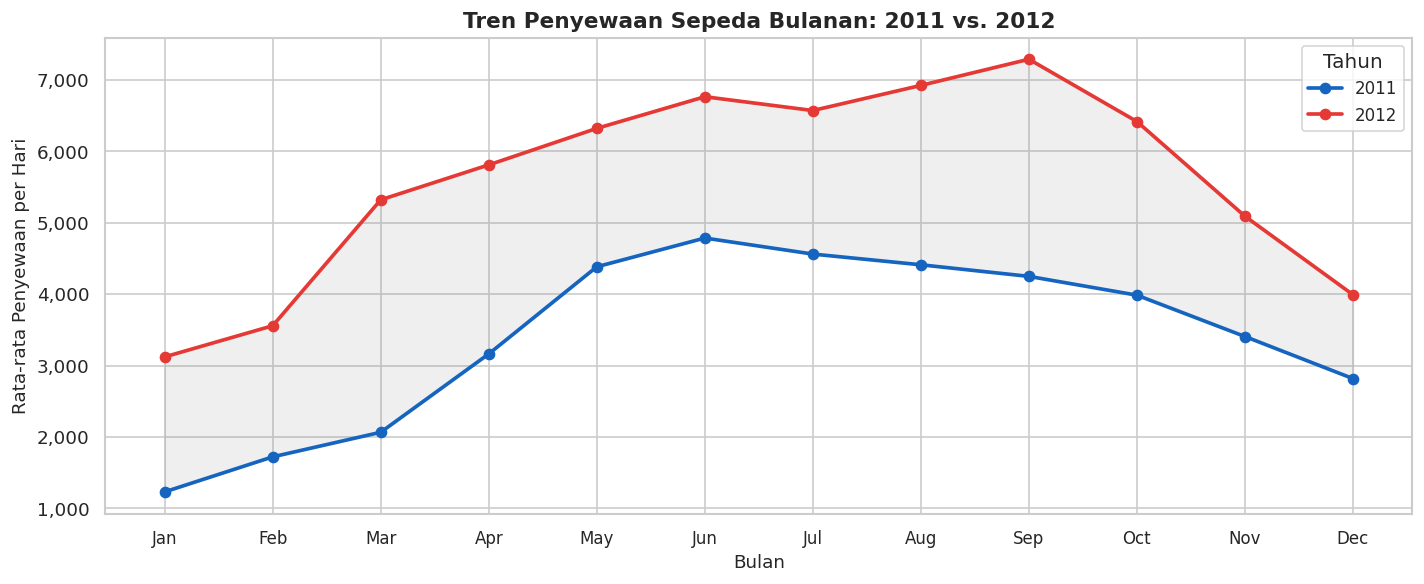

In [19]:
monthly = df_day.groupby(['year','mnth'])['cnt'].mean().reset_index()
bulan_label = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(12, 5))
for yr, color in [(2011,'#1565C0'),(2012,'#E53935')]:
    d = monthly[monthly['year']==yr].set_index('mnth')['cnt']
    ax.plot(d.index, d.values, marker='o', linewidth=2.2, label=str(yr), color=color, markersize=6)

ax.set_xticks(range(1,13))
ax.set_xticklabels(bulan_label, fontsize=10)
ax.set_xlabel('Bulan', fontsize=11)
ax.set_ylabel('Rata-rata Penyewaan per Hari', fontsize=11)
ax.set_title('Tren Penyewaan Sepeda Bulanan: 2011 vs. 2012', fontsize=13, fontweight='bold')
ax.legend(title='Tahun', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.fill_between(range(1,13),
    monthly[monthly['year']==2011].set_index('mnth')['cnt'].reindex(range(1,13)),
    monthly[monthly['year']==2012].set_index('mnth')['cnt'].reindex(range(1,13)),
    alpha=0.12, color='grey')
plt.tight_layout()
plt.savefig('viz_monthly_trend.png', bbox_inches='tight')
plt.show()


## 5. Analisis Lanjutan: Clustering (Binning Penggunaan Harian)

**Tujuan:** Mengelompokkan hari-hari berdasarkan volume penyewaan ke dalam kategori rendah, sedang, tinggi, dan sangat tinggi menggunakan teknik binning. Hasil pengelompokan ini membantu operator menentukan kebutuhan armada berbeda untuk setiap tier.

In [20]:
# Binning cnt into 4 demand clusters
q25, q50, q75 = df_day['cnt'].quantile([0.25, 0.50, 0.75])
cnt_max = df_day['cnt'].max()

bins_cnt   = [0, q25, q50, q75, cnt_max]
labels_cnt = ['Rendah', 'Sedang', 'Tinggi', 'Sangat Tinggi']
df_day['demand_cluster'] = pd.cut(df_day['cnt'], bins=bins_cnt, labels=labels_cnt,
                                   include_lowest=True)

cluster_summary = df_day.groupby('demand_cluster', observed=True).agg(
    Jumlah_Hari=('cnt','count'),
    Min_Sewa=('cnt','min'),
    Max_Sewa=('cnt','max'),
    Mean_Sewa=('cnt','mean'),
    Pct_Workingday=('workingday','mean')
).round(1)
cluster_summary['Pct_Workingday'] = (cluster_summary['Pct_Workingday'] * 100).round(1)
print(cluster_summary.to_string())


                Jumlah_Hari  Min_Sewa  Max_Sewa  Mean_Sewa  Pct_Workingday
demand_cluster                                                            
Rendah                  183        22      3141     1933.6            60.0
Sedang                  183      3163      4548     3916.7            70.0
Tinggi                  182      4549      5936     5128.1            70.0
Sangat Tinggi           183      5976      8714     7042.4            70.0


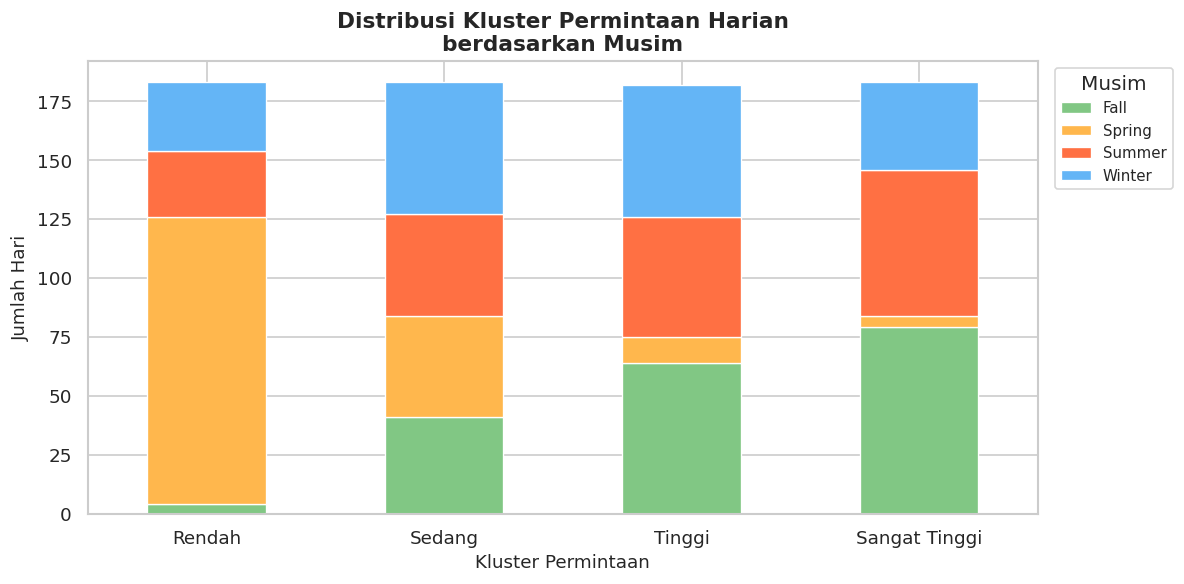

In [21]:
# Stacked bar: cluster composition by season
cluster_season = df_day.groupby(['demand_cluster','season_label'], observed=True).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
cluster_season.reindex(['Rendah','Sedang','Tinggi','Sangat Tinggi']).plot(
    kind='bar', stacked=True, ax=ax,
    color=['#81C784','#FFB74D','#FF7043','#64B5F6'],
    edgecolor='white', linewidth=0.8
)
ax.set_xlabel('Kluster Permintaan', fontsize=11)
ax.set_ylabel('Jumlah Hari', fontsize=11)
ax.set_title('Distribusi Kluster Permintaan Harian\nberdasarkan Musim', fontsize=13, fontweight='bold')
ax.legend(title='Musim', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('viz_cluster_season.png', bbox_inches='tight')
plt.show()


## 6. Conclusion & Recommendation

### Kesimpulan

**Pertanyaan 1 – Pola Penyewaan Per Jam:**
- Pada **hari kerja**, penyewaan memiliki pola **bimodal** (dua puncak): pagi pukul **08:00** (rata-rata ~470 sewa) dan sore pukul **17:00–18:00** (rata-rata ~461–461 sewa). Pola ini mencerminkan penggunaan sepeda sebagai moda transportasi komuter.
- Pada **hari libur/akhir pekan**, pola lebih landai dengan puncak tunggal di siang hari sekitar pukul **12:00–14:00**, mencerminkan penggunaan untuk rekreasi.
- Volume total hari kerja lebih tinggi daripada hari libur, namun distribusinya lebih terkonsentrasi pada jam sibuk.

**Pertanyaan 2 – Pengaruh Faktor Lingkungan:**
- **Musim Fall** memiliki rata-rata penyewaan tertinggi (~5.644/hari), diikuti Summer (~4.992/hari). **Musim Spring** memiliki rata-rata terendah (~2.604/hari), jauh di bawah musim lainnya.
- **Kondisi cuaca cerah** menghasilkan rata-rata penyewaan ~4.876/hari, sedangkan cuaca hujan/salju ringan menurunkan rata-rata hingga ~1.803/hari (turun ~63%).
- **Suhu hangat (20–30°C)** menghasilkan volume sewa tertinggi, sementara suhu sangat dingin (0–10°C) menghasilkan volume terendah. Terdapat hubungan positif yang kuat antara suhu dan jumlah penyewaan.

### Rekomendasi Action Item

1. **Optimasi distribusi sepeda berbasis jam (Hari Kerja):**  
   Tambahkan armada di stasiun-stasiun utama sebelum pukul 07:30 dan 16:30 untuk mengantisipasi lonjakan permintaan komuter. Kurangi armada di jam sepi (01:00–05:00) untuk efisiensi biaya operasional.

2. **Strategi promosi berbasis cuaca & musim:**  
   Jalankan kampanye promosi (diskon, loyalty points) selama musim Spring dan pada hari-hari cuaca mendung/hujan ringan untuk menstimulasi permintaan. Saat musim Fall/Summer dan cuaca cerah, fokus pada kapasitas dan ketersediaan armada.

3. **Perencanaan armada berbasis kluster permintaan:**  
   Gunakan model kluster 4-tier (Rendah/Sedang/Tinggi/Sangat Tinggi) sebagai input perencanaan harian. Hari dengan prediksi cluster 'Sangat Tinggi' (terutama musim Fall, cuaca cerah, suhu 20–30°C) perlu penambahan armada dan personel pemeliharaan.
